<a href="https://colab.research.google.com/github/Rima6699/Amir-datmin/blob/main/tugas_data_mining_amir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()


df = pd.read_csv('fifa_player_performance_market_value.csv')
df.head()

Saving fifa_player_performance_market_value.csv to fifa_player_performance_market_value (2).csv


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

,player_id,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,27.952500,76.866786,81.563929,27.135714,19.261786,12.015000,2250.101429,90.565500,2.527857
std,808.434702,6.750192,9.921113,9.755799,15.979627,11.567858,7.188459,1295.461829,52.078881,1.699445
min,1.000000,17.000000,60.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.670000,0.000000
25%,700.750000,22.000000,68.000000,73.000000,13.750000,9.000000,6.000000,1131.250000,45.355000,1.000000
50%,1400.500000,28.000000,77.000000,82.000000,27.000000,19.000000,12.000000,2251.000000,89.170000,3.000000
75%,2100.250000,34.000000,85.000000,90.000000,41.000000,30.000000,18.000000,3366.250000,136.682500,4.000000
max,2800.000000,39.000000,94.000000,98.000000,54.000000,39.000000,24.000000,4497.000000,179.960000,5.000000


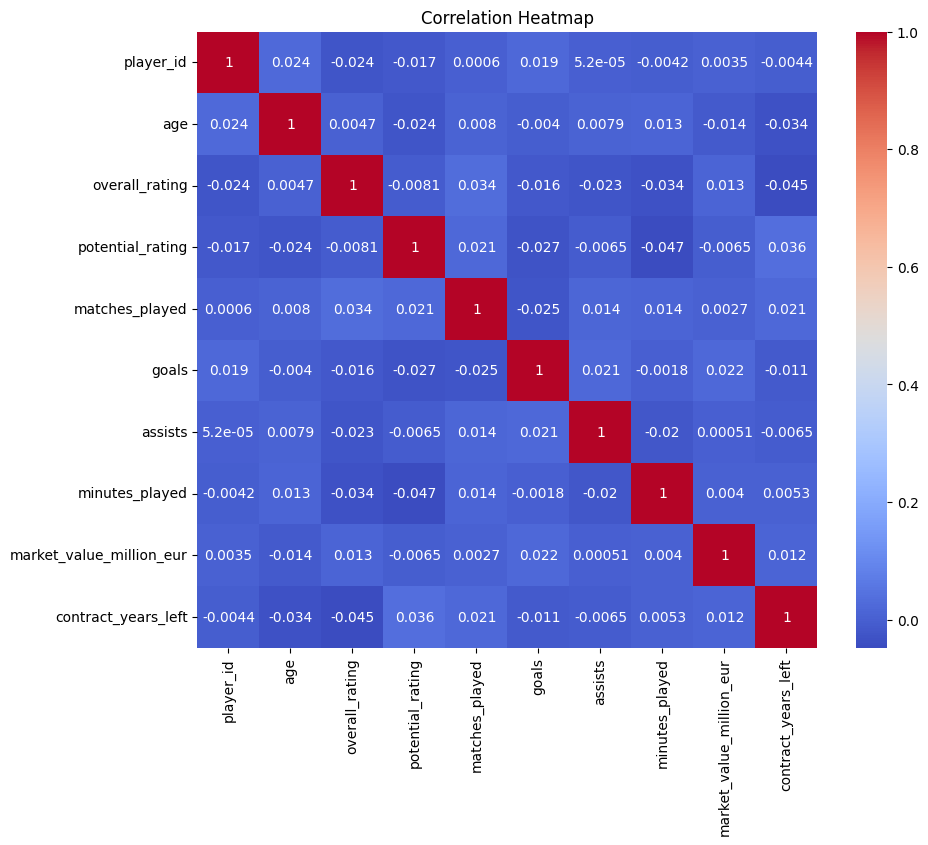

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Copy dataset
df_model = df.copy()

# Inisialisasi encoder
le = LabelEncoder()

# Kolom kategorikal
categorical_cols = ["nationality", "club", "position", "injury_prone", "transfer_risk_level"]

# Encoding
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,4,3,8,65,87,8,6,14,2976,122.51,3,0,1
1,2,Player_2,36,2,1,8,90,76,19,3,18,2609,88.47,5,0,0
2,3,Player_3,31,3,2,6,75,91,34,12,15,1158,20.24,3,0,2
3,4,Player_4,27,6,4,5,90,86,35,18,13,145,164.29,0,1,2
4,5,Player_5,24,1,3,1,84,96,41,6,6,2226,121.34,4,0,1


In [ ]:
#market_value_million_eur
X = df_model.drop(["player_id", "player_name", "market_value_million_eur"], axis=1)
y = df_model["market_value_million_eur"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah fitur: 13
Jumlah data: 2800


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Data training: (2240, 13)
Data testing: (560, 13)


In [ ]:
lr = LinearRegression()

# Training
lr.fit(X_train, y_train)

# Prediksi
y_pred_lr = lr.predict(X_test)

# Evaluasi
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print("MSE:", mse_lr)
print("R2 Score:", r2_lr)

=== Linear Regression ===
MSE: 2875.7177280220753
R2 Score: -0.006023470833022682


In [ ]:
rf = RandomForestRegressor(random_state=42)

# Training
rf.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test)

# Evaluasi
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)

=== Random Forest ===
MSE: 2950.959050273821
R2 Score: -0.03234543401604717


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [mse_lr, mse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

results

,Model,MSE,R2 Score
0,Linear Regression,2875.717728,-0.006023
1,Random Forest,2950.959050,-0.032345


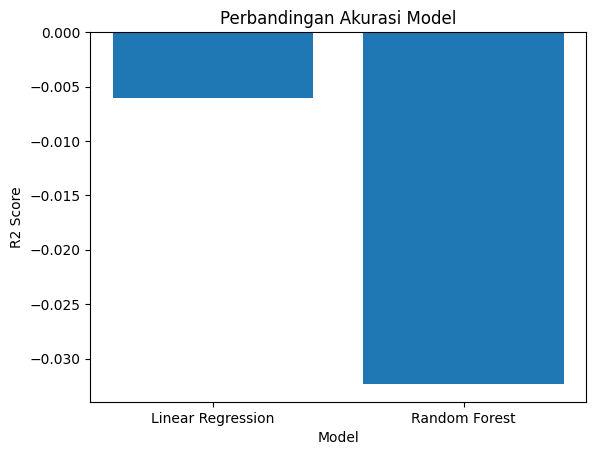

In [ ]:
plt.figure()
plt.bar(results["Model"], results["R2 Score"])

plt.title("Perbandingan Akurasi Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")

plt.show()

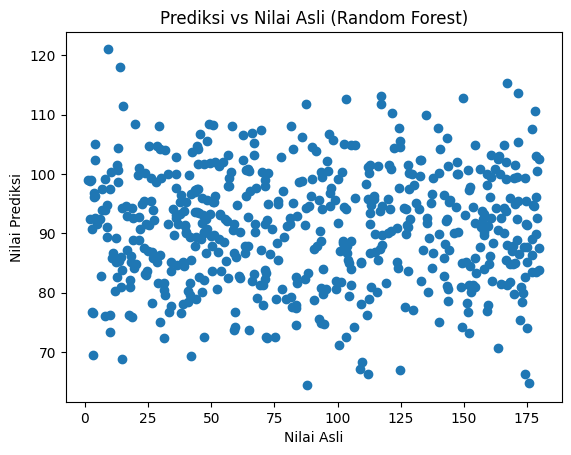

In [ ]:
plt.figure()

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Nilai Asli")
plt.ylabel("Nilai Prediksi")
plt.title("Prediksi vs Nilai Asli (Random Forest)")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance

,Feature,Importance
9,minutes_played,0.146503
6,matches_played,0.105962
7,goals,0.100968
5,potential_rating,0.100238
4,overall_rating,0.098114
8,assists,0.094037
0,age,0.089478
3,position,0.060920
1,nationality,0.058465
2,club,0.055030


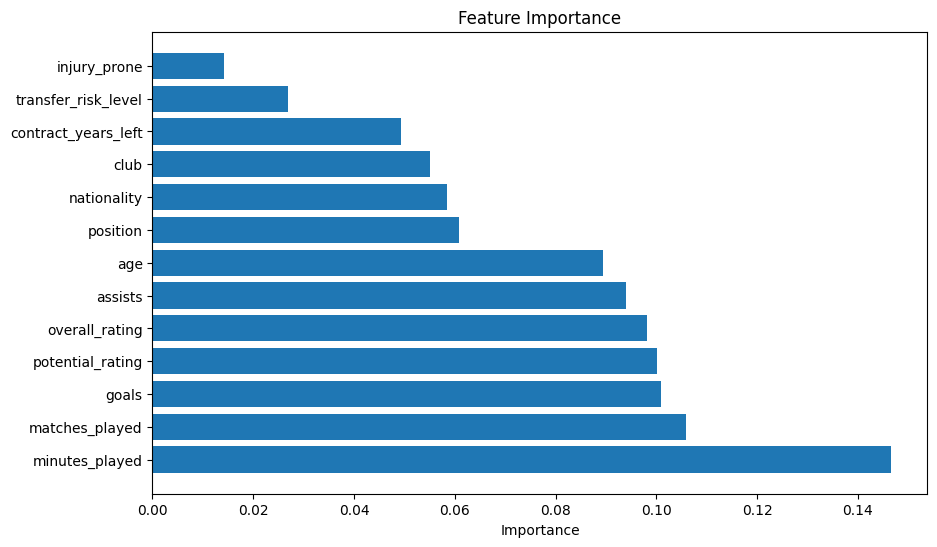

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()